**Libraries**

In [24]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

import numpy as np
from numpy.typing import NDArray

from bloodmoon.types import CoordEquatorial
from bloodmoon.io import simulation_files
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.mask import codedmask, count
from bloodmoon.mask import decode

import darksun as ds
from darksun.data import DataLoader, CatalogueLoader
from darksun.benchmarking import source_catalogue_data

**Analysis Methods**

In [29]:
from bloodmoon.io import SimulationDataLoader
from bloodmoon.coords import shift2pos, equatorial2shift

def equatorial2pos(
    sdl: SimulationDataLoader,
    camera: CodedMaskCamera,
    ra: float,
    dec: float,
) -> tuple[int, int]:
    """
    Convert equatorial coordinates (RA/Dec) to sky pixel position.

    Args:
        sdl: SimulationDataLoader containing camera pointings
        camera: A CodedMaskCamera object containing sky shape and binning information.
        ra: Right ascension in degrees [0, 360].
        dec: Declination in degrees [-90, 90].

    Returns:
        Tuple of (row, column) indices in the discrete sky image grid.

    Notes:
        - RA must be normalized to [0, 360) degree range.
    """
    return shift2pos(camera, *equatorial2shift(sdl, camera, ra, dec))

def get_source_coords(
    sourceID: str,
    catalogue: CatalogueLoader,
) -> CoordEquatorial:
    """Retrieves the source RA/Dec coords from catalogue."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    return CoordEquatorial(data['RA'], data['DEC'])

def gen_source_sg(
    coords: CoordEquatorial,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    E_min: float | None = None,
    E_max: float | None = None,
) -> NDArray:
    """
    Generates the source shadowgram with the photons in the
    specified energy range [`E_min`, `E_max`] keV.
    """
    # retrieve all photons from selected direction
    total_photons = ds.select_source_photons(coords, sdl.DLdata)
    # select photons in input energy range
    total_photons = ds.filter_data(total_photons, E_min=E_min, E_max=E_max, coords=None)
    # remove photons fell in detector plane dead zone
    sg = count(camera, total_photons)[0] * (camera.bulk > 0)
    return sg

type EnergyRange = tuple[float | None, float | None]

def plot_source_psf(
    sourceID: str,
    catalogue: CatalogueLoader,
    sdl: DataLoader,
    camera: CodedMaskCamera,
    energy_range: EnergyRange | tuple[EnergyRange, ...],
) -> None:
    """Plots the PSF profiles of a source in a given energy range."""
    energy_range_ = (
        (energy_range,) if isinstance(energy_range[0], (float | None)) else energy_range
    )

    coords = get_source_coords(sourceID, catalogue)
    pos = equatorial2pos(sdl, camera, coords.ra, coords.dec)
    slit_fine, slit_coarse = ds.psf_extension(camera)

    for (emin, emax) in energy_range_:
        sky = decode(
            camera, gen_source_sg(coords, sdl, camera, emin, emax),
        )
        ds.slices_plot(
            sky=sky,
            pos=pos,
            crp=(slit_coarse + 5, slit_fine + 5),
            source=sourceID,
            cameraID=f'[{emin}, {emax}] keV',
        )
    
    return None

**Mask and Data Specifics**

In [26]:
MASK_FITS: str = "wfm_mask_NTHT_20250725.fits"

#SKYFIELD: str = "GalacticCentre"
SKYFIELD: str = "IROSDummy"
#DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"
#DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_fmin0.0945_2-50keV_1ks"
DATA_FITS: str = "iros_benchmark_2-50keV_mask_050_1040x17_1ks"

ANALYSIS_ID: str = "singleCAM_iros_benchmark_detected"

ID_CAMERA_A: str = "cam1a"
ID_CAMERA_B: str = "cam1b"
DATASET: str = "reconstructed"

UPS_X: int = 10
UPS_Y: int = 1

VIGNETTING: bool = True
PSFY: bool = True

**Load Mask and Data**

In [27]:
# load filepaths
mask_path, simul_data, save_path = _handle_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
    run_name=ANALYSIS_ID,
)
wfm: CodedMaskCamera = codedmask(mask_path, UPS_X, UPS_Y)
filepaths: dict[str, dict[str, Path]] = simulation_files(simul_data)

# data from camera A
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catalogueA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])

# data from camera B
sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
catalogueB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

**Sources Profiles**

Selected 906779/3561427 photons.


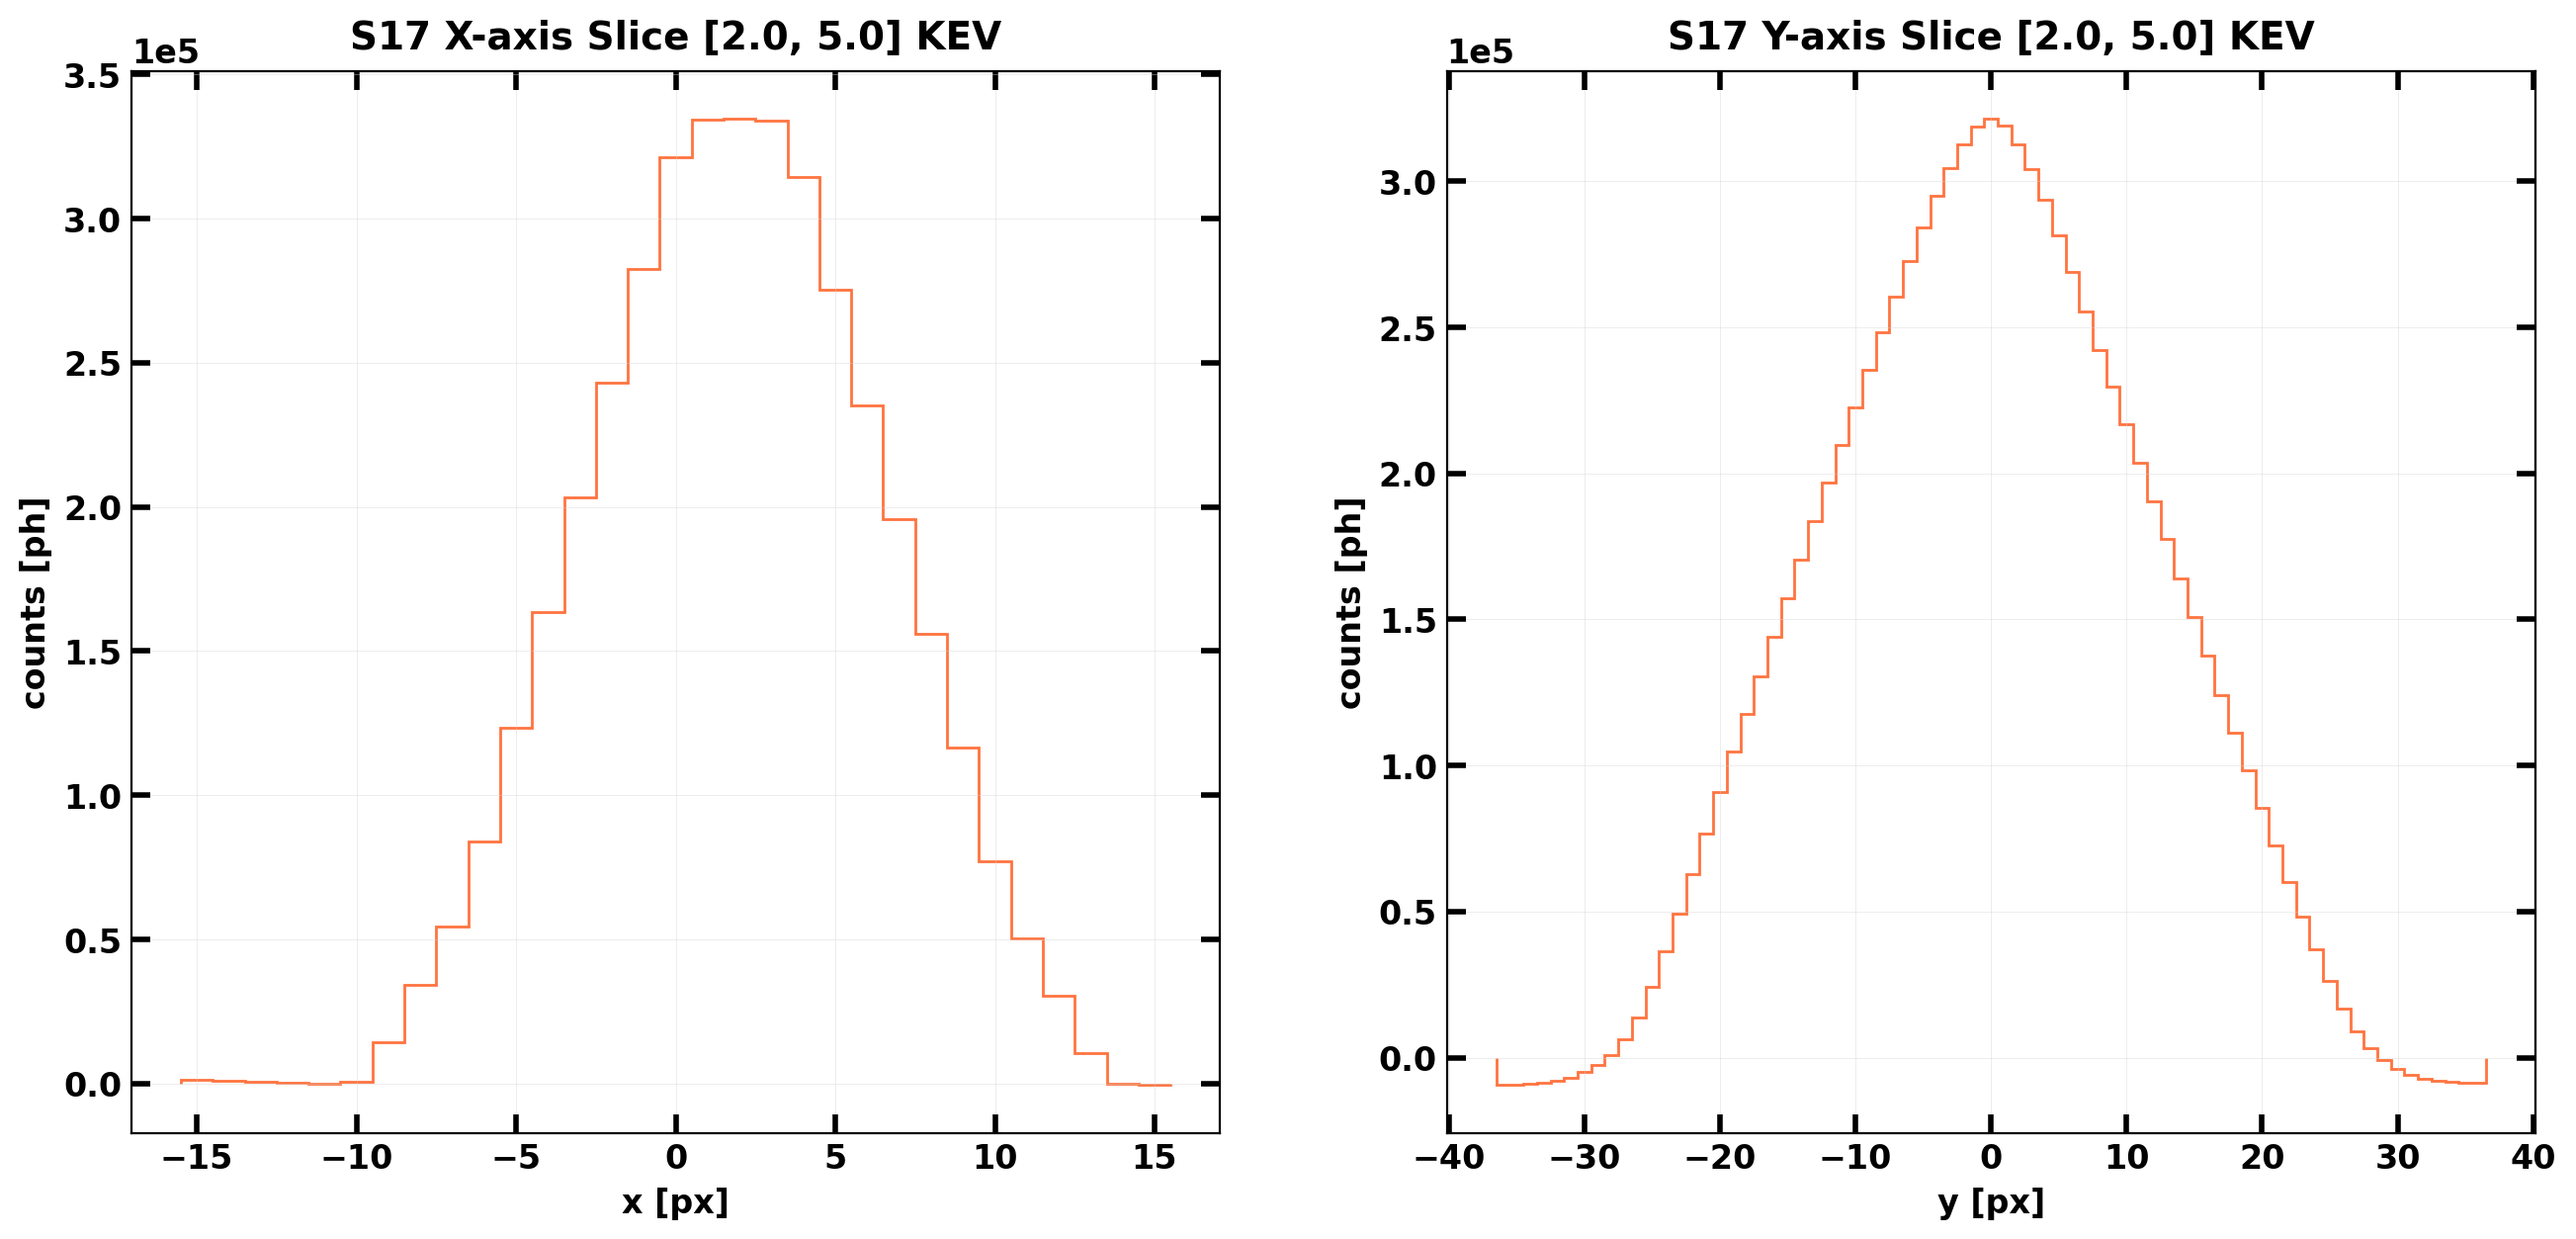

Selected 906779/3561427 photons.


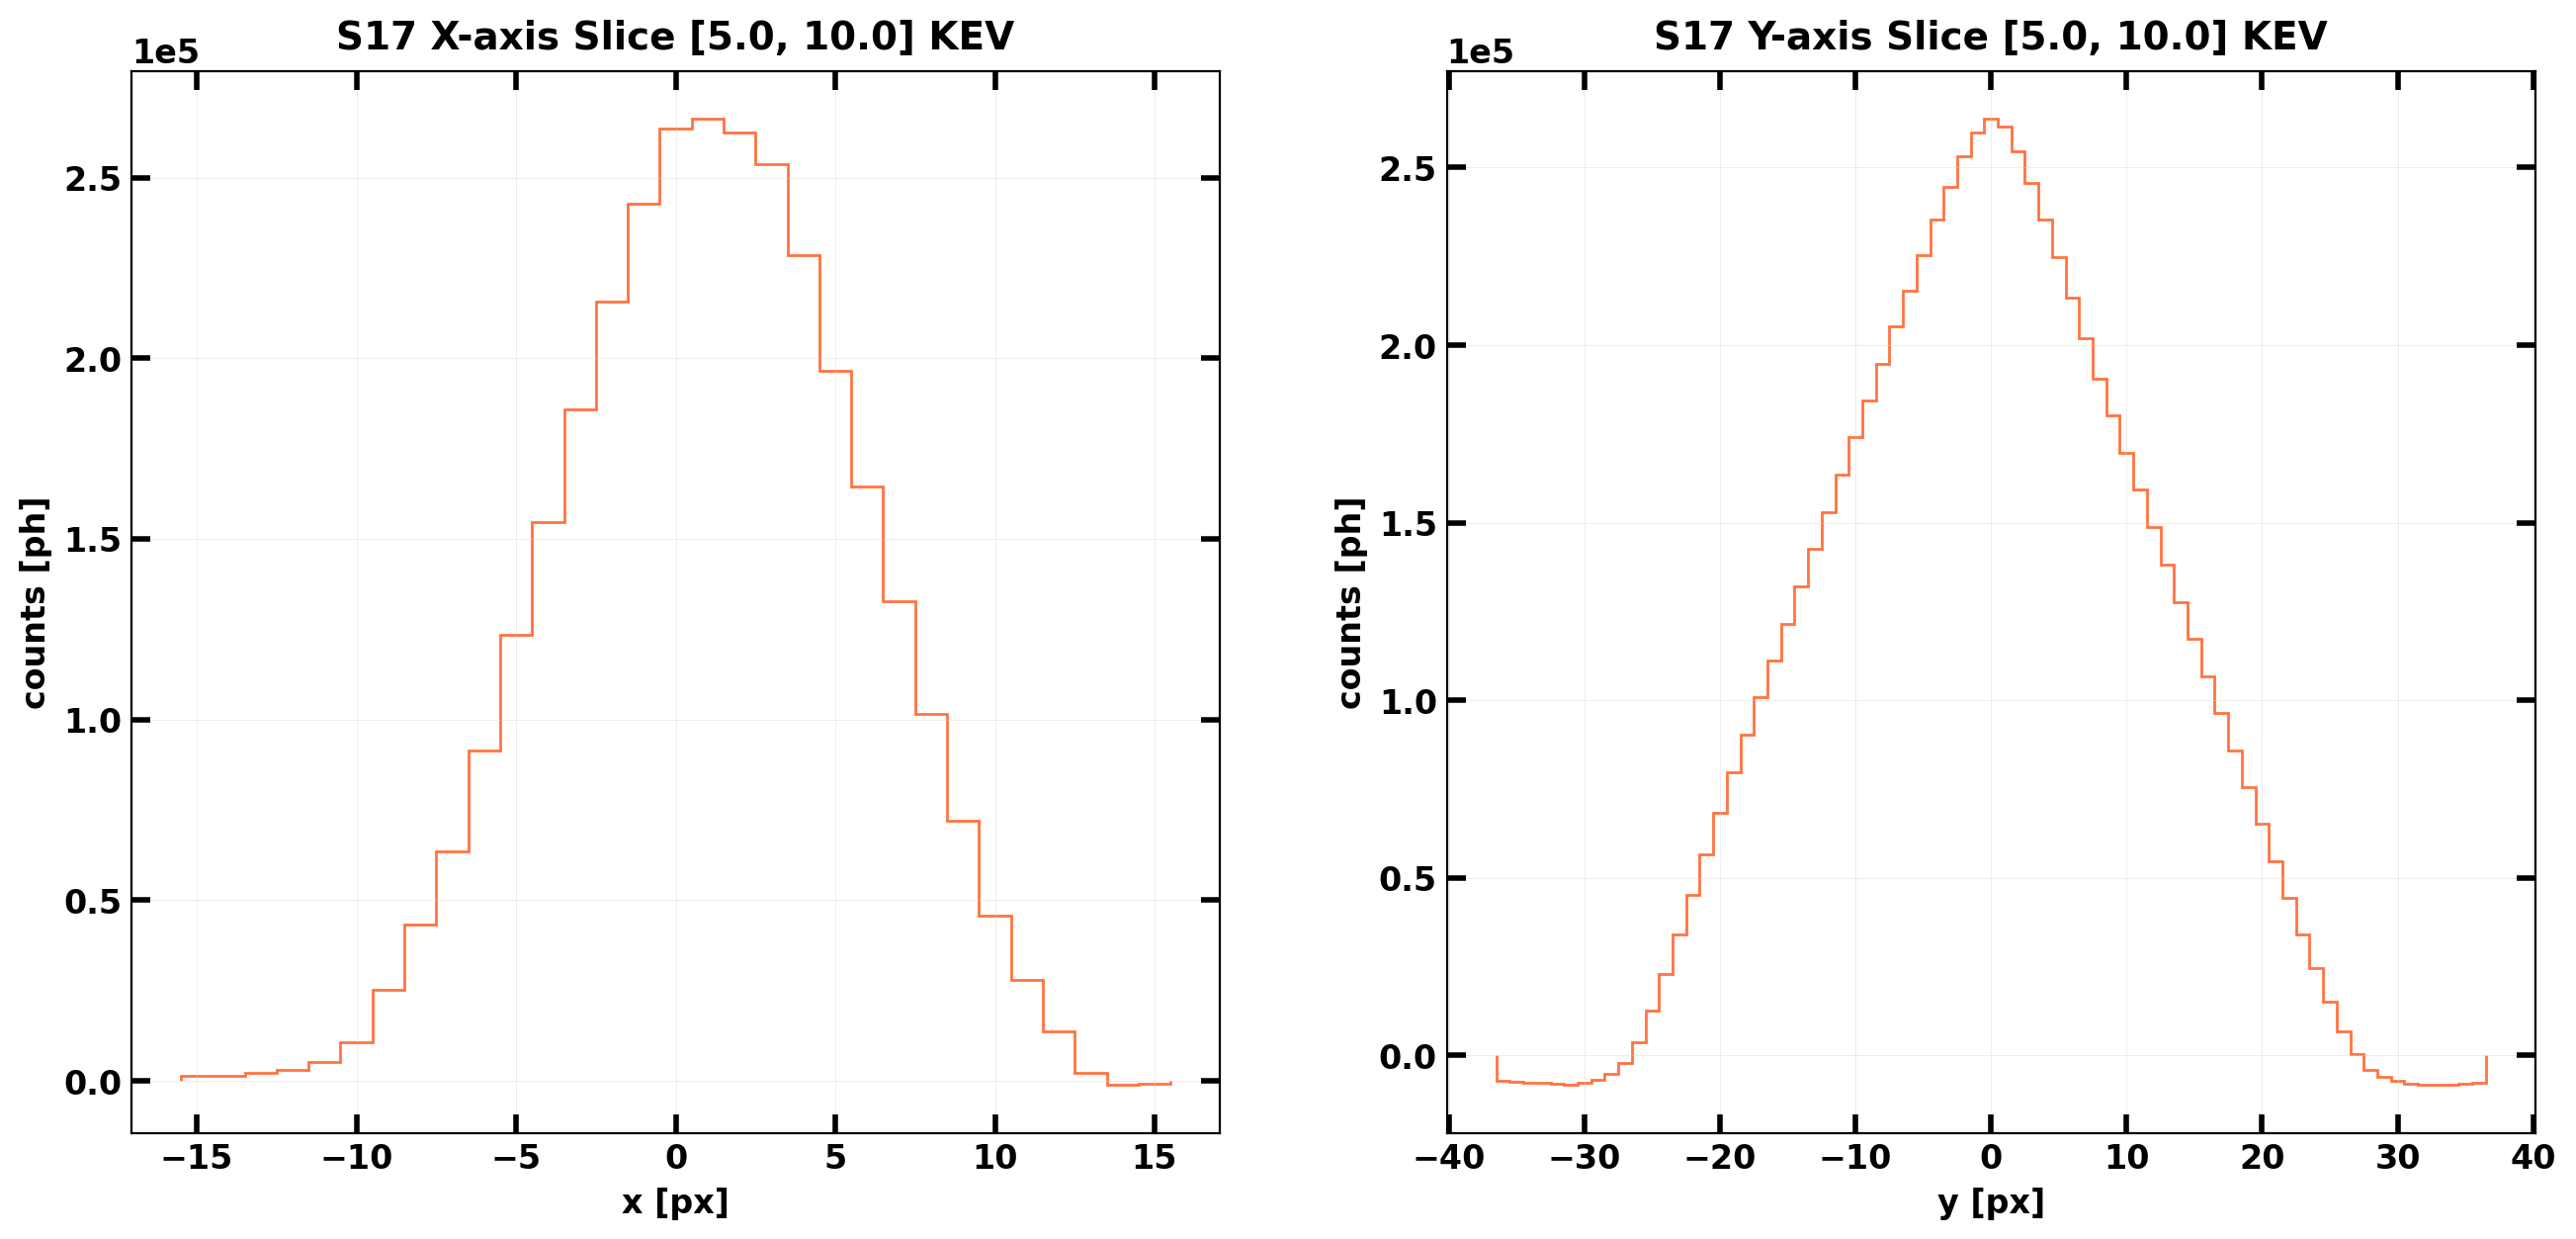

Selected 906779/3561427 photons.


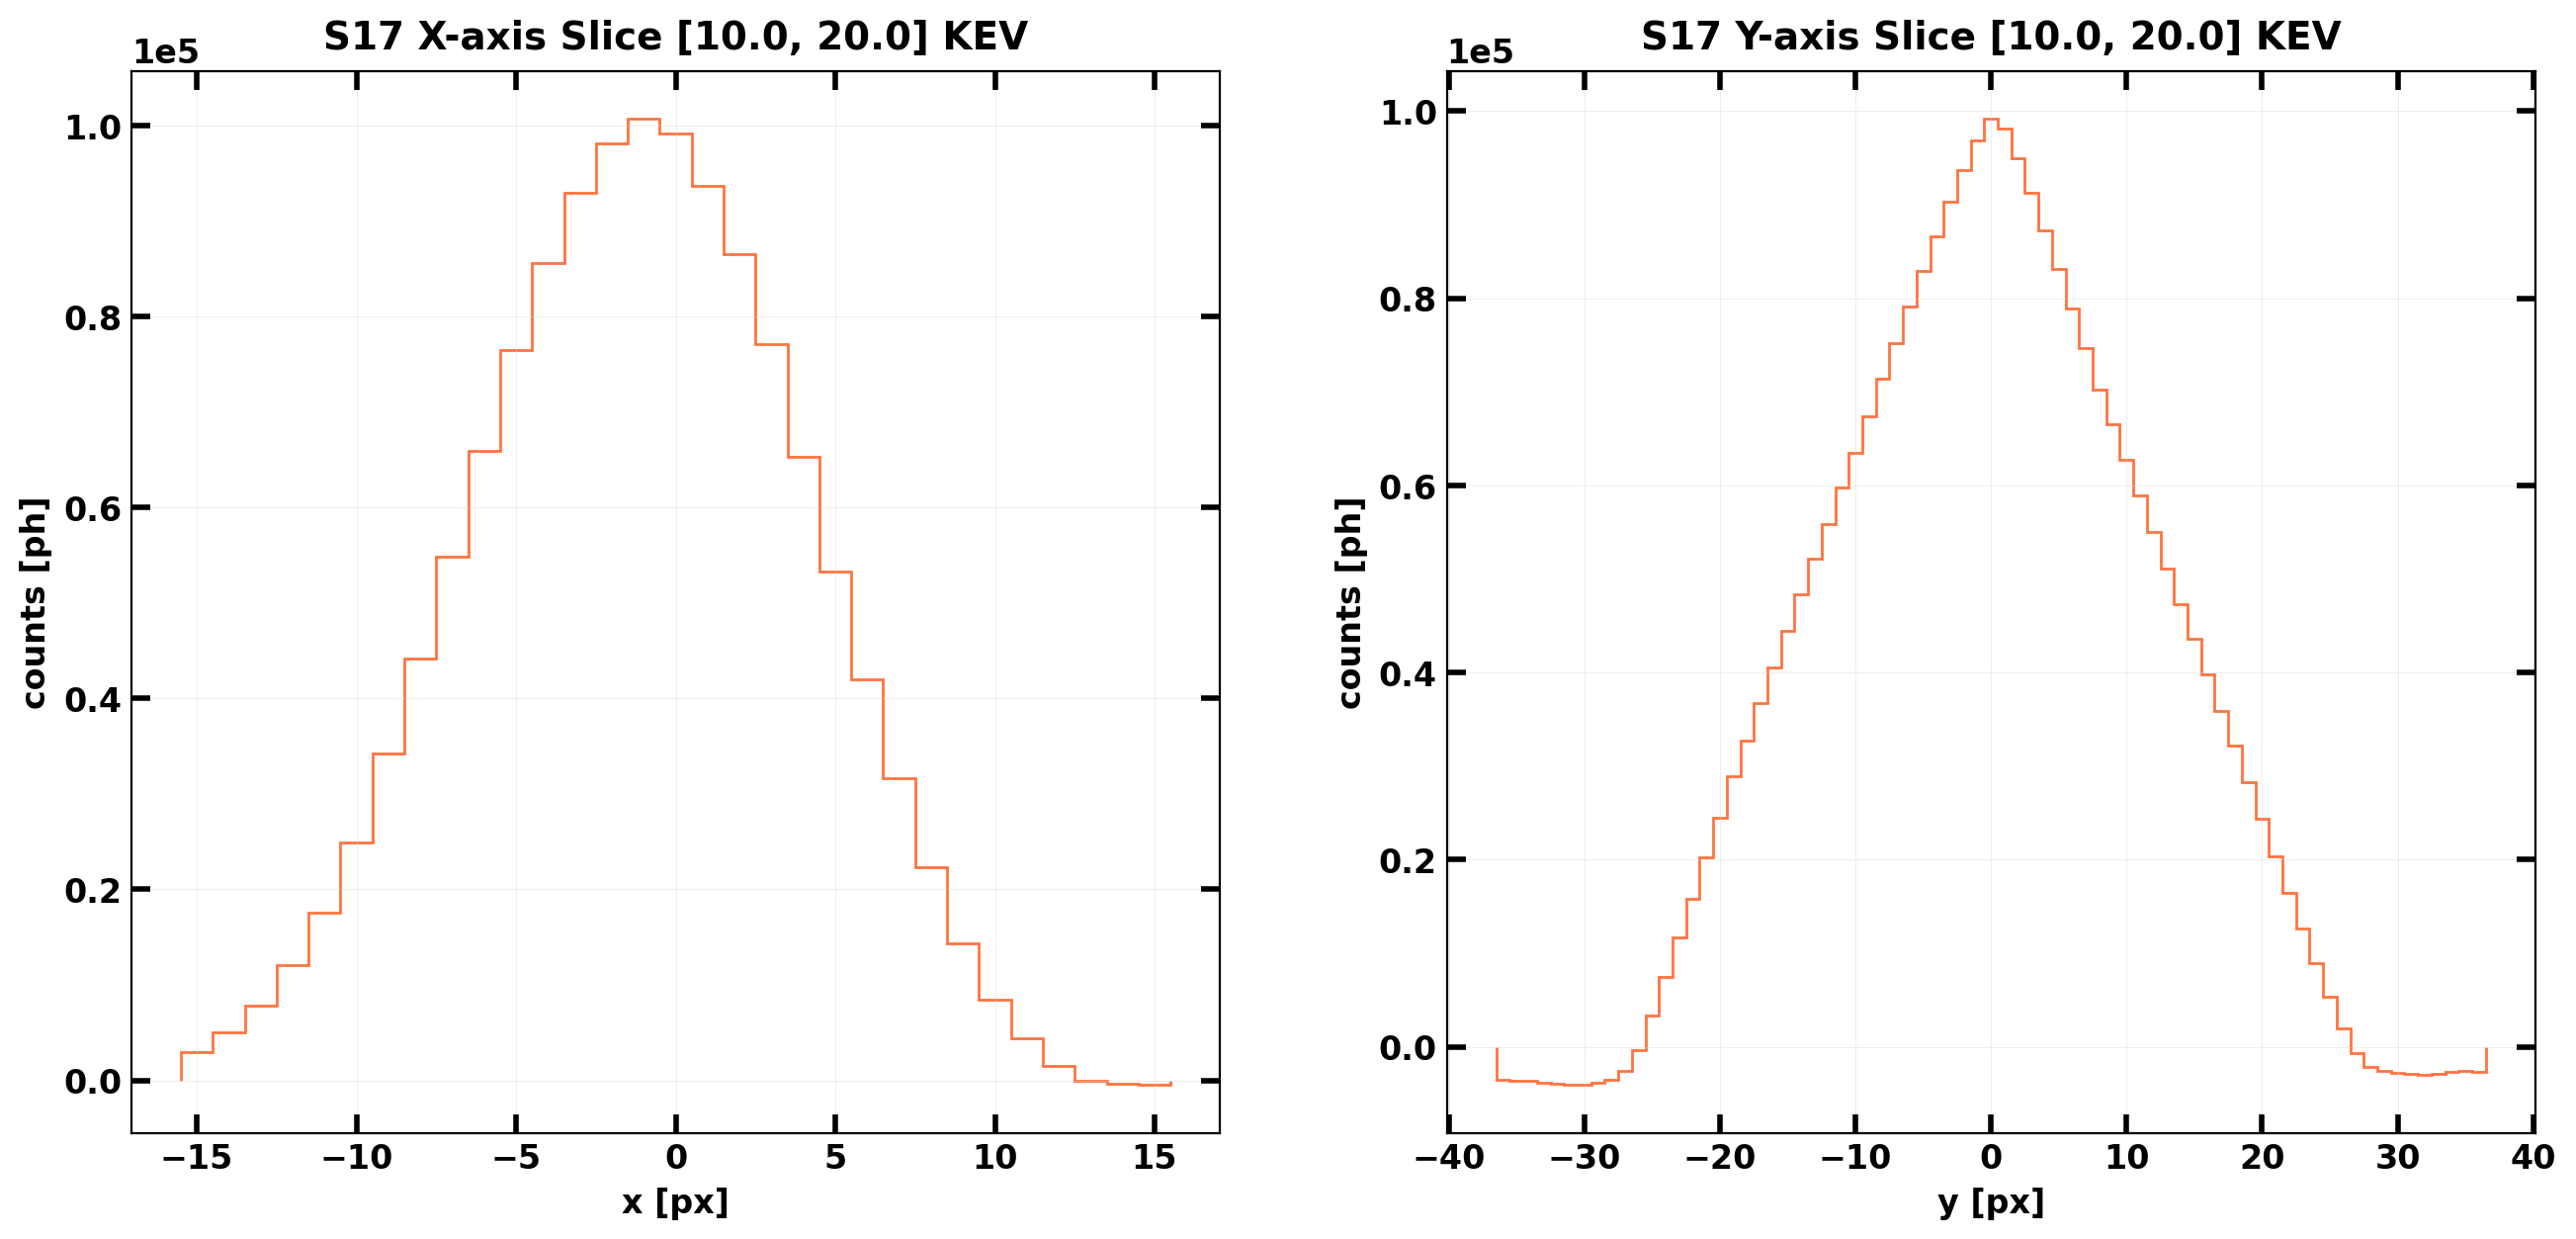

Selected 906779/3561427 photons.


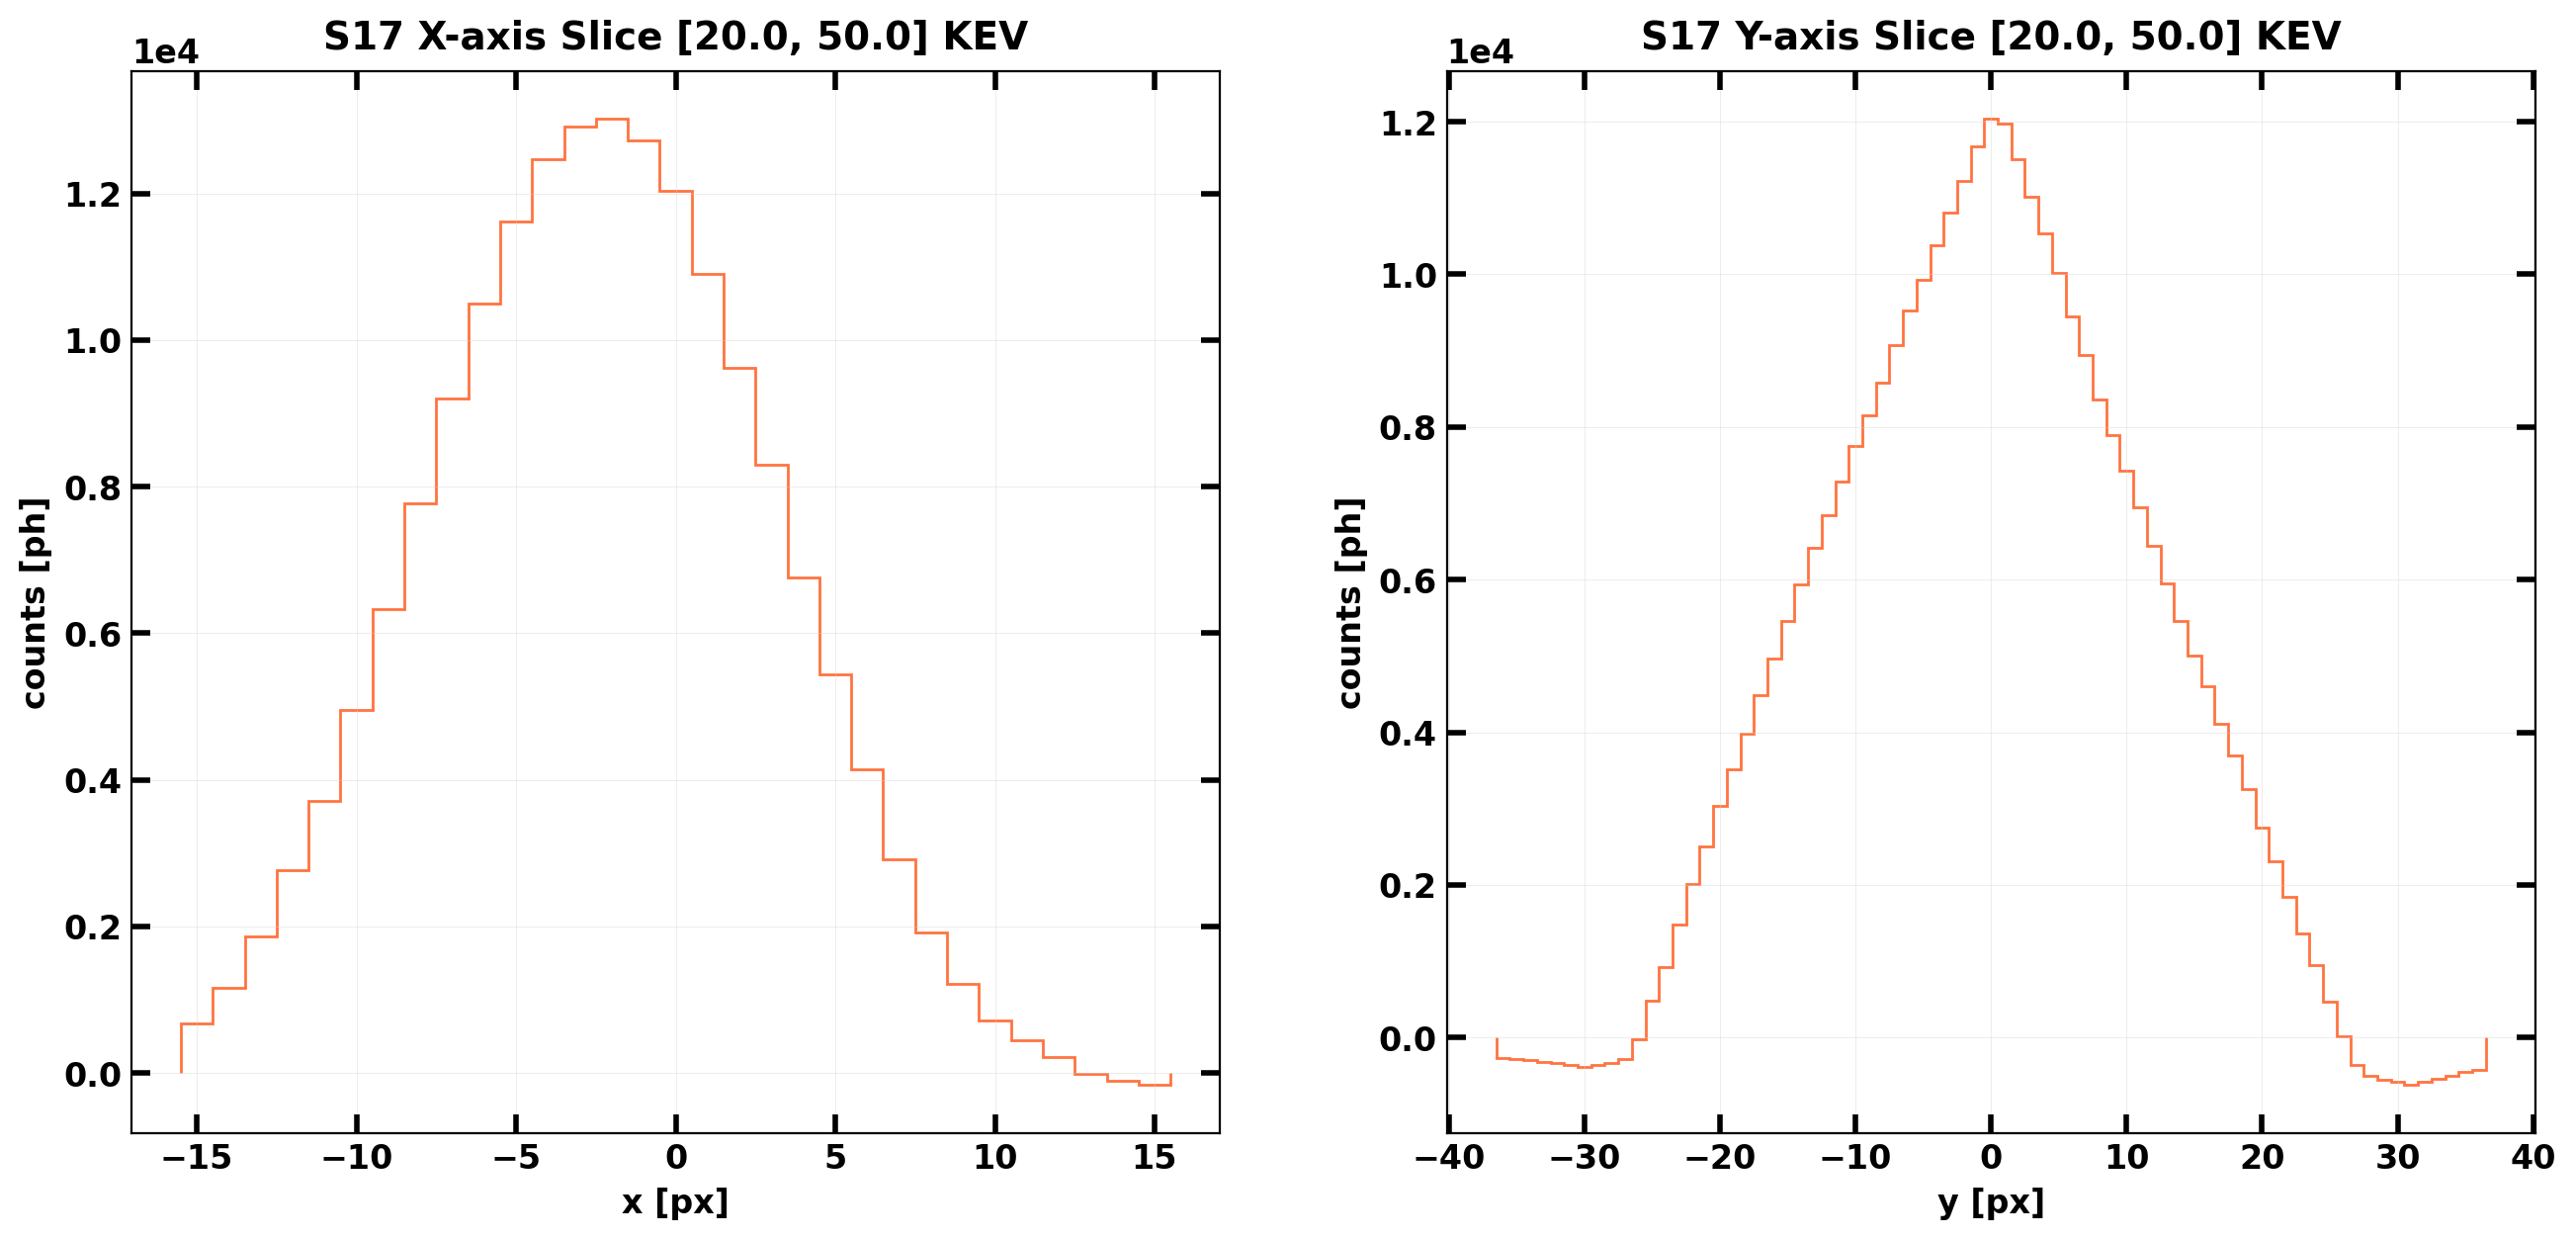

In [ ]:
# check sources PSF profiles wrt photons energy range here:
# url: https://arxiv.org/pdf/1408.6533

energy_range: tuple[EnergyRange, ...] = (
    (2.0, 5.0), (5.0, 10.0), (10.0, 20.0), (20.0, 50.0),
)
plot_source_psf('s17', catalogueA, sdlA, wfm, energy_range)

Selected 906779/3561427 photons.


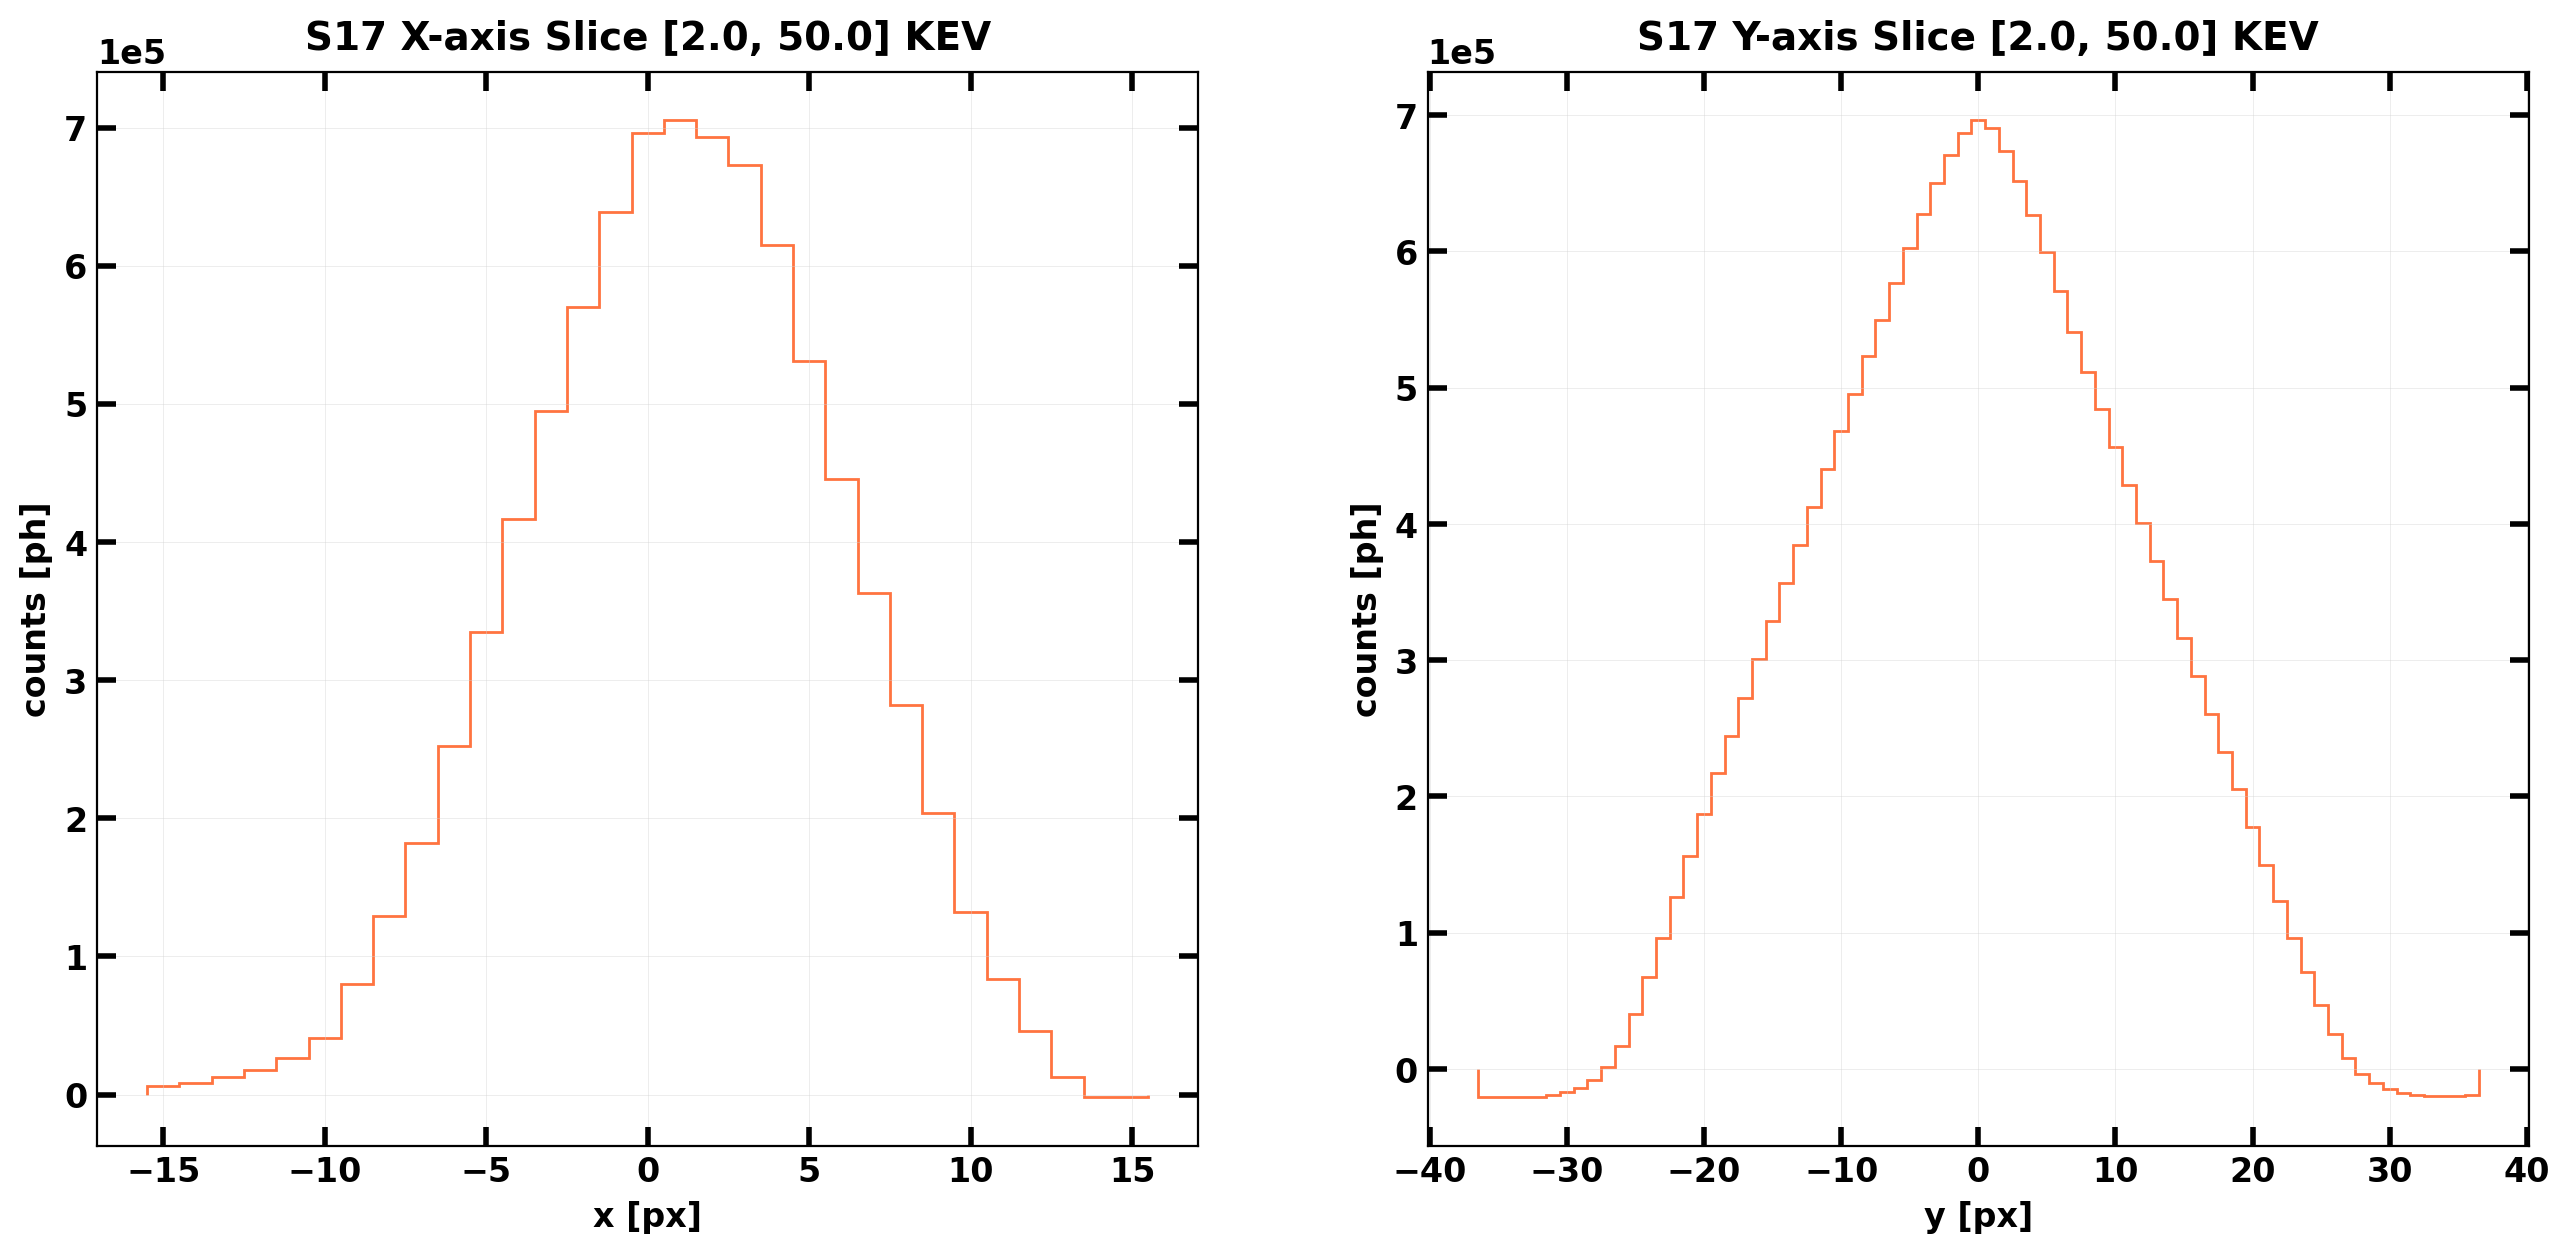

In [32]:
plot_source_psf('s17', catalogueA, sdlA, wfm, (2.0, 50.0))